# Asian Option Variance-Reduction Benchmark

This notebook benchmarks Monte Carlo estimators for a fixed **arithmetic Asian call** contract under GBM:

1. Plain Monte Carlo
2. Antithetic variates
3. Control variate using geometric Asian payoff with closed-form expectation

Outputs:
- Standard error vs wall-clock time for each method
- Variance reduction factor (VRF) vs number of paths
- Speed to target CI half-width (default: 1 cent)



In [1]:
import sys
from pathlib import Path
from time import perf_counter
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").exists() and (REPO_ROOT.parent / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.asian_geometric import price_geometric_asian
from src.gbm import simulate_gbm_paths
from src.mc import mc_price_asian_arithmetic
from src.payoffs import asian_arithmetic_payoff
from src.rng import RNG
from src.variance_reduction import control_variate, mc_price_asian_arithmetic_antithetic

Z_95 = norm.ppf(0.975)

In [2]:
contract = {
    "S0": 100.0,
    "K": 95.0,
    "r": 0.015,
    "T": 1.0,
    "sigma": 0.25,
}

steps = 64
n_grid = np.array([5_000, 10_000, 20_000, 50_000, 100_000, 200_000, 400_000], dtype=int)
n_replications = 30
master_seed = 20260215

target_ci_halfwidth = 0.01  # 1 cent

methods = ["plain", "antithetic", "control_variate"]

raw = {
    method: {
        int(N): {"estimate": [], "stderr": [], "ci_halfwidth": [], "time_s": []}
        for N in n_grid
    }
    for method in methods
}

seed_rng = np.random.default_rng(master_seed)

## Geometric Asian Control Expectation

`EY_geo` is the closed-form price of a geometric Asian call — the known expectation used by the control-variate estimator. Computing it once outside the benchmark loop avoids redundant calls at every replication.

In [3]:
EY_geo = price_geometric_asian(
    contract["S0"], contract["K"], contract["r"], contract["sigma"], contract["T"], steps, "call"
)

## Benchmark Loop

For each N in `n_grid`, the loop runs `n_replications` independent trials. Seeds are shared across methods at each replication so differences in stderr reflect the estimator, not random variation in the seed.

In [4]:
discount = np.exp(-contract["r"] * contract["T"])

for N in n_grid:
    seeds = seed_rng.integers(low=1, high=2**31 - 1, size=n_replications, dtype=np.int64)

    for seed in seeds:
        # 1) Plain MC.
        t0 = perf_counter()
        rng_plain = RNG(seed=int(seed))
        paths_plain = simulate_gbm_paths(
            contract["S0"], contract["r"], contract["sigma"], contract["T"], steps, int(N), rng=rng_plain
        )
        res_plain = mc_price_asian_arithmetic(paths_plain, contract["K"], contract["r"], contract["T"], "call")
        dt_plain = perf_counter() - t0

        raw["plain"][int(N)]["estimate"].append(float(res_plain["price"]))
        raw["plain"][int(N)]["stderr"].append(float(res_plain["stderr"]))
        raw["plain"][int(N)]["ci_halfwidth"].append(float(Z_95 * res_plain["stderr"]))
        raw["plain"][int(N)]["time_s"].append(float(dt_plain))

        # 2) Antithetic MC.
        n_anti = int(N if N % 2 == 0 else N + 1)
        t0 = perf_counter()
        rng_anti = RNG(seed=int(seed))
        res_anti = mc_price_asian_arithmetic_antithetic(
            contract["S0"],
            contract["K"],
            contract["r"],
            contract["T"],
            contract["sigma"],
            steps,
            n_anti,
            rng_anti,
            "call",
        )
        dt_anti = perf_counter() - t0

        raw["antithetic"][int(N)]["estimate"].append(float(res_anti["price"]))
        raw["antithetic"][int(N)]["stderr"].append(float(res_anti["stderr"]))
        raw["antithetic"][int(N)]["ci_halfwidth"].append(float(Z_95 * res_anti["stderr"]))
        raw["antithetic"][int(N)]["time_s"].append(float(dt_anti))

        # 3) Control variate.
        t0 = perf_counter()
        rng_cv = RNG(seed=int(seed))
        paths_cv = simulate_gbm_paths(
            contract["S0"], contract["r"], contract["sigma"], contract["T"], steps, int(N), rng=rng_cv
        )

        x = discount * np.asarray(asian_arithmetic_payoff(paths_cv, contract["K"], "call"), dtype=float)
        geo_avg = np.exp(np.mean(np.log(paths_cv[:, 1:]), axis=1))
        y = discount * np.asarray(np.maximum(geo_avg - contract["K"], 0.0), dtype=float)

        est_cv, stderr_cv, _ = control_variate(x, y, EY_geo)
        dt_cv = perf_counter() - t0

        raw["control_variate"][int(N)]["estimate"].append(float(est_cv))
        raw["control_variate"][int(N)]["stderr"].append(float(stderr_cv))
        raw["control_variate"][int(N)]["ci_halfwidth"].append(float(Z_95 * stderr_cv))
        raw["control_variate"][int(N)]["time_s"].append(float(dt_cv))

## Aggregation

Aggregate replication-level results into per-method, per-N summary statistics for plotting. The variance across replications (`var_estimate`) is used to compute the variance reduction factor.

In [5]:
summary = {
    method: {
        "N": [],
        "mean_time_s": [],
        "mean_stderr": [],
        "mean_ci_halfwidth": [],
        "var_estimate": [],
    }
    for method in methods
}

for method in methods:
    for N in n_grid:
        rec = raw[method][int(N)]
        est = np.asarray(rec["estimate"], dtype=float)
        se = np.asarray(rec["stderr"], dtype=float)
        hw = np.asarray(rec["ci_halfwidth"], dtype=float)
        tm = np.asarray(rec["time_s"], dtype=float)

        summary[method]["N"].append(int(N))
        summary[method]["mean_time_s"].append(float(tm.mean()))
        summary[method]["mean_stderr"].append(float(se.mean()))
        summary[method]["mean_ci_halfwidth"].append(float(hw.mean()))
        summary[method]["var_estimate"].append(float(est.var(ddof=1) if est.size > 1 else 0.0))

    for k in summary[method]:
        summary[method][k] = np.asarray(summary[method][k], dtype=float)

# VRF = Var(plain) / Var(method) at each N.
vrf = {"N": n_grid.astype(float)}
plain_var = summary["plain"]["var_estimate"]
for method in methods:
    denom = summary[method]["var_estimate"]
    vrf[method] = np.where(denom > 0.0, plain_var / denom, np.nan)

## Plot 1: Efficiency Frontier

Standard error vs wall-clock time on log-log axes. Lower-left is better — a method that achieves lower stderr in less time dominates. The control variate typically moves both left (faster per run) and down (lower error) relative to plain MC.

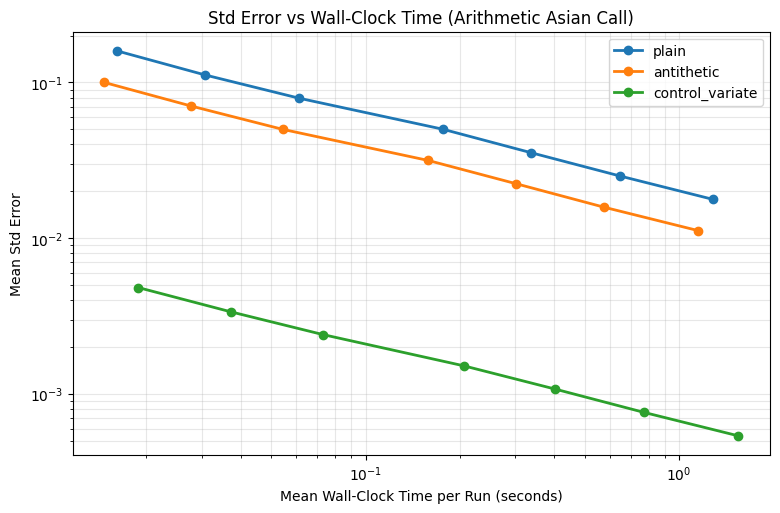

In [6]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for method in methods:
    ax.loglog(
        summary[method]["mean_time_s"],
        summary[method]["mean_stderr"],
        marker="o",
        linewidth=2,
        label=method,
    )
ax.set_xlabel("Mean Wall-Clock Time per Run (seconds)")
ax.set_ylabel("Mean Std Error")
ax.set_title("Std Error vs Wall-Clock Time (Arithmetic Asian Call)")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.show()
plt.close(fig)

## Plot 2: Convergence

Standard error vs number of simulated paths on log-log axes. All three methods should decay as N^{-1/2}; the vertical separation between curves reflects the variance reduction factor.

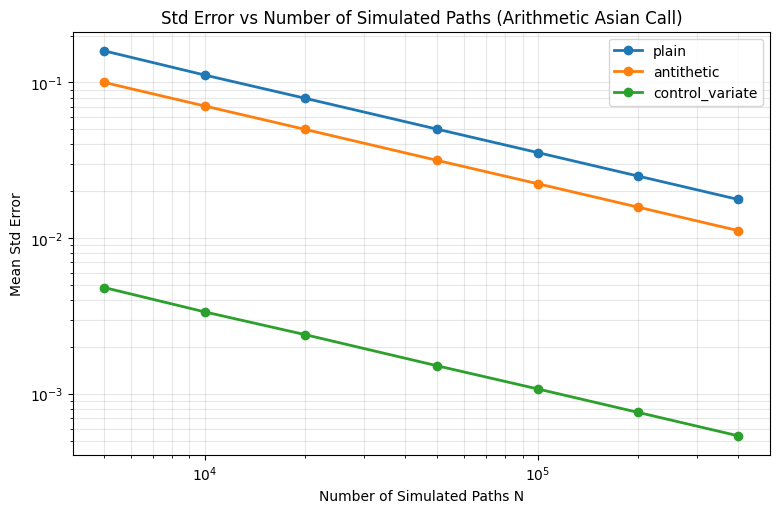

In [7]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for method in methods:
    ax.loglog(
        summary[method]["N"],
        summary[method]["mean_stderr"],
        marker="o",
        linewidth=2,
        label=method,
    )
ax.set_xlabel("Number of Simulated Paths N")
ax.set_ylabel("Mean Std Error")
ax.set_title("Std Error vs Number of Simulated Paths (Arithmetic Asian Call)")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.show()
plt.close(fig)

## Speed-to-Target Summary

The smallest mean wall-clock time at which each method's mean CI half-width falls at or below `target_ci_halfwidth`. If a method shows "not reached", increase the upper end of `n_grid` in the parameters cell and re-run.

In [9]:
speed_table = {}
for method in methods:
    hw = summary[method]["mean_ci_halfwidth"]
    tm = summary[method]["mean_time_s"]
    feasible = np.where(hw <= target_ci_halfwidth)[0]
    speed_table[method] = float(np.min(tm[feasible])) if feasible.size > 0 else np.nan

plain_time = speed_table["plain"]

print("Target CI half-width:", target_ci_halfwidth)
print("\nTime to target (seconds):")
for method, t in speed_table.items():
    print(f"{method:>20s}: {t:.6f}" if np.isfinite(t) else f"{method:>20s}: not reached")

print("\nSpeedup vs plain (plain_time / method_time):")
for method, t in speed_table.items():
    if method == "plain":
        print(f"{method:>20s}: 1.000x")
    elif np.isfinite(plain_time) and np.isfinite(t) and t > 0:
        print(f"{method:>20s}: {plain_time / t:.3f}x")
    else:
        print(f"{method:>20s}: n/a")

Target CI half-width: 0.01

Time to target (seconds):
               plain: not reached
          antithetic: not reached
     control_variate: 0.018833

Speedup vs plain (plain_time / method_time):
               plain: 1.000x
          antithetic: n/a
     control_variate: n/a
